# Предиктивное обслуживание электротранспорта — Базовое моделирование (NASA Li-ion Battery Aging Dataset)

## Описание датасета

**Датасет:** NASA Li-ion Battery Aging Dataset (полный набор BatteryAgingARC, батареи B0005–B0056).

**Источник данных для этого ноутбука:** очищенный датасет `final_df_clean.csv`, сформированный в ноутбуке **`battery_eda.ipynb`** (разведочный анализ и очистка).

---

### **Назначение ноутбука**

Это **второй ноутбук** в цепочке дипломного проекта. Он решает задачу **базового моделирования**: прогноз емкости батареи на текущем цикле по телеметрии предыдущих циклов.

| Параметр | Значение |
|:--------|:--------|
| **Целевая переменная** | `capacity` (Ач) — емкость текущего цикла разряда |
| **Признаки** | `cycle`, `capacity_lag_1`, `capacity_lag_2`, `capacity_lag_3` |
| **Модели** | Random Forest (бейзлайн), LSTM (timesteps=3) |
| **Датасет** | `final_df_clean` из `battery_eda.ipynb` (2765 строк, 33 батареи) |

**Предварительное условие:** перед запуском этого ноутбука выполните `battery_eda.ipynb` — он сформирует файл `/battery_dataset/final_df_clean.csv`.


## **Часть 1. Загрузка очищенного датасета**

Загружаем `final_df_clean.csv`, сформированный в `battery_eda.ipynb`. Этот датасет уже прошел:
- удаление дубликатов и физически невозможных значений;
- интерполяцию скрытых пропусков (capacity==0.0, сбои стенда NASA);
- сглаживание выбросов-пиков (|Δcapacity| > 0.3 Ah);
- расчет `soh` и `health_state` (4-уровневая система предупреждений: ЗЕЛЕНЫЙ/ЖЕЛТЫЙ/ОРАНЖЕВЫЙ/КРАСНЫЙ).

### **Блок 1: Импорт библиотек и загрузка данных**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print('Библиотеки успешно импортированы.')


Библиотеки успешно импортированы.


In [2]:
# === Загрузка очищенного датасета из battery_eda.ipynb ===
DATA_FILE = os.path.join('battery_dataset', 'final_df_clean.csv')

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f'Файл {DATA_FILE} не найден. Сначала выполните ноутбук battery_eda.ipynb — '
        'он сформирует final_df_clean.csv в папке battery_dataset/.')

final_df_clean = pd.read_csv(DATA_FILE)

# Для обратной совместимости с кодом ниже используем alias final_df
final_df = final_df_clean.copy()

print(f'=== Загружен очищенный датасет ===')
print(f'Файл: {DATA_FILE}')
print(f'Строк: {len(final_df)}')
print(f'Батарей: {final_df["battery_id"].nunique()}')
print(f'Колонки: {list(final_df.columns)}')
print(f'\nПервые 5 строк:')
display(final_df.head())


=== Загружен очищенный датасет ===
Файл: battery_dataset\final_df_clean.csv
Строк: 2765
Батарей: 33
Колонки: ['battery_id', 'cycle', 'type', 'capacity', 'soh', 'health_state']

Первые 5 строк:


,battery_id,cycle,type,capacity,soh,health_state
0,B0005,2,discharge,1.856487,1.000000,ЗЕЛЕНЫЙ
1,B0005,4,discharge,1.846327,0.994527,ЗЕЛЕНЫЙ
2,B0005,6,discharge,1.835349,0.988614,ЗЕЛЕНЫЙ
3,B0005,8,discharge,1.835263,0.988567,ЗЕЛЕНЫЙ
4,B0005,10,discharge,1.834646,0.988235,ЗЕЛЕНЫЙ


In [3]:
final_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   battery_id    2765 non-null   str    
 1   cycle         2765 non-null   int64  
 2   type          2765 non-null   str    
 3   capacity      2765 non-null   float64
 4   soh           2765 non-null   float64
 5   health_state  2765 non-null   str    
dtypes: float64(2), int64(1), str(3)
memory usage: 204.1 KB


In [4]:
final_df.describe()


,cycle,capacity,soh
count,2765.000000,2765.000000,2765.000000
mean,165.355515,1.331554,0.781031
std,143.504627,0.456491,0.230767
min,1.000000,0.044092,0.032681
25%,53.000000,1.150153,0.743769
50%,121.000000,1.424147,0.839512
75%,239.000000,1.671477,0.915355
max,614.000000,2.035338,1.000000


### **Блок 2: Визуализация деградации на очищенном датасете**

Строим кривые деградации емкости для нескольких батарей на очищенном датасете `final_df_clean` и пересчитываем SOH для наглядности.

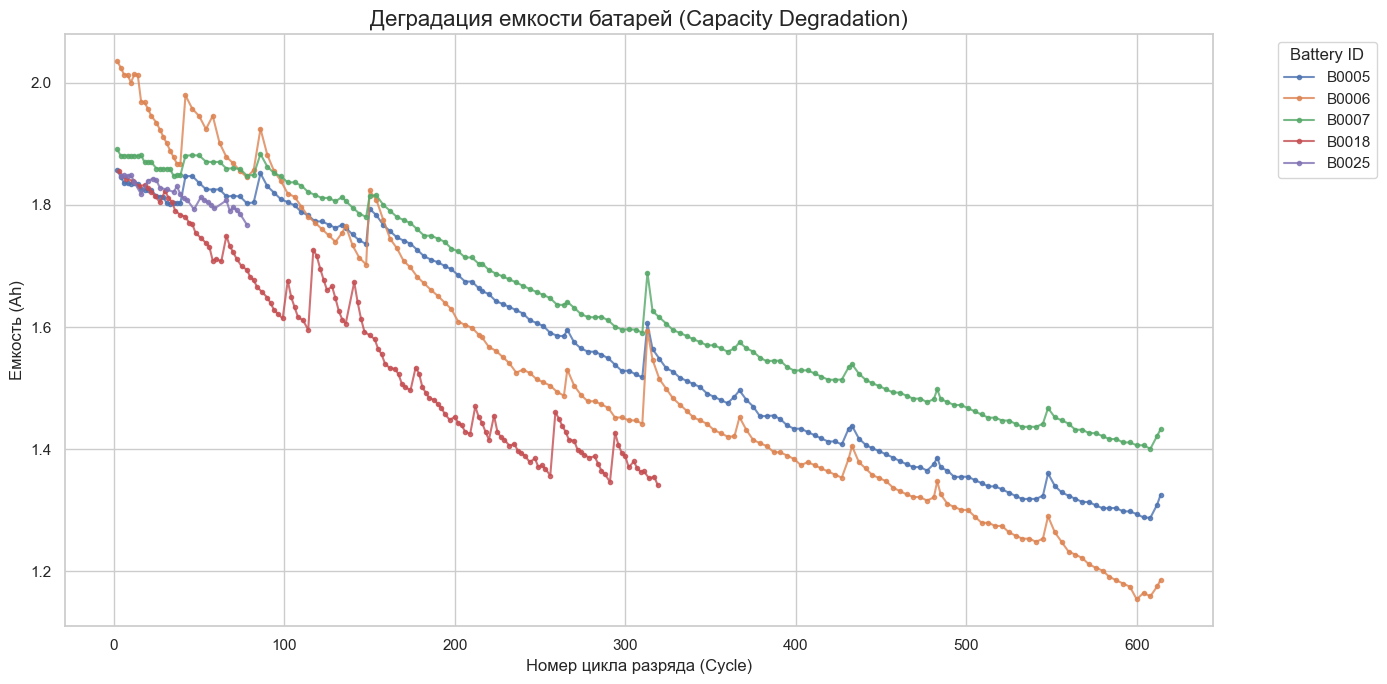

Пример данных с добавленным SOH:


,battery_id,cycle,capacity,soh
0,B0005,2,1.856487,1.000000
1,B0005,4,1.846327,0.994527
2,B0005,6,1.835349,0.988614
3,B0005,8,1.835263,0.988567
4,B0005,10,1.834646,0.988235


In [5]:
plt.figure(figsize=(14, 7))

# Берем первые 5 батарей для примера, чтобы график не был перегружен
sample_batteries = final_df['battery_id'].unique()[:5]

for batt_id in sample_batteries:
    subset = final_df[final_df['battery_id'] == batt_id]
    # Сортируем, чтобы линия была непрерывной
    subset = subset.sort_values('cycle')
    plt.plot(subset['cycle'], subset['capacity'], label=batt_id, marker='o', markersize=3, alpha=0.8)

plt.title('Деградация емкости батарей (Capacity Degradation)', fontsize=16)
plt.xlabel('Номер цикла разряда (Cycle)', fontsize=12)
plt.ylabel('Емкость (Ah)', fontsize=12)
plt.legend(title='Battery ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Посчитаем SOH (State of Health) для понимания "здоровья" батарей
# SOH = Текущая емкость / Максимальная емкость (устанавливаем первый цикл или макс как 100%)
# Для простоты возьмем максимум каждой батареи как 100%
soh_data = []
for batt_id in final_df['battery_id'].unique():
    sub = final_df[final_df['battery_id'] == batt_id]
    max_cap = sub['capacity'].max()
    sub['soh'] = sub['capacity'] / max_cap
    soh_data.append(sub)

final_df_with_soh = pd.concat(soh_data)
print("Пример данных с добавленным SOH:")
display(final_df_with_soh[['battery_id', 'cycle', 'capacity', 'soh']].head())

Видим ниспадающие кривые деградации. Начальная емкость варьирует: ~2.0 Ач у батарей B0005–B0007, ~1.7 Ач у B0046–B0048, ~1.1–1.3 Ач у B0045/B0049–B0051/B0053–B0056. К концу жизни емкость снижается до 0.7–1.4 Ач в зависимости от батареи. Кривые подтверждают монотонный тренд старения с разной скоростью.

## **Часть 2. Подготовка признаков и базовая модель**

Цель — превратить задачу в задачу обучения с учителем (Supervised Learning). Будем предсказывать емкость текущего цикла.

### **Блок 3: Feature Engineering (лаги)**

Модели сложно работать просто с номером цикла. Для обучения моделей (и RF, и LSTM) нам нужно превратить задачу в «Supervised Learning».

Добавим «скользящие окна». Будем предсказывать емкость текущего цикла, зная емкость предыдущих 3 циклов.


In [6]:
from sklearn.model_selection import train_test_split

# Сортировка данных для корректного создания окон
df_model = final_df.copy().sort_values(by=['battery_id', 'cycle'])

# Функция для создания лагов (предыдущих значений)
def add_lags(df, lags=[1, 2, 3]):
    temp_df = df.copy()
    for lag in lags:
        # Создаем признак: емкость lag циклов назад
        # Сдвигаем данные внутри каждой группы (battery_id)
        # lag=1 означает емкость ПРЕДЫДУЩЕГО цикла
        temp_df[f'capacity_lag_{lag}'] = temp_df.groupby('battery_id')['capacity'].shift(lag)
    return temp_df

# Добавляем лаги
df_model = add_lags(df_model)

# Удаляем строки с NaN (появились из-за сдвига в начале жизни каждой батареи)
df_model = df_model.dropna()

print("Данные после добавления лагов (признаков):")
display(df_model.head())

# Определяем X (признаки) и y (целевая переменная)
# Признаки: Номер цикла + Емкость 3-х прошлых циклов
FEATURES = ['cycle', 'capacity_lag_1', 'capacity_lag_2', 'capacity_lag_3']
TARGET = 'capacity'

X = df_model[FEATURES]
y = df_model[TARGET]

# Разделение на train/test (по времени! Последние 20% циклов каждой батареи - в тест)
# Это корректнее для временных рядов, чем простой random_split
# Для временных рядов важно, чтобы тестом должны быть ПРЕДПОСЛЕДНИЕ циклы (самые "старые" батареи или конец жизни)
def split_train_test(df, test_size=0.2):
    train_list = []
    test_list = []
    for batt_id in df['battery_id'].unique():
        batt_df = df[df['battery_id'] == batt_id]
        split_idx = int(len(batt_df) * (1 - test_size))
        train_list.append(batt_df.iloc[:split_idx])
        test_list.append(batt_df.iloc[split_idx:])
    
    return pd.concat(train_list), pd.concat(test_list)

train_df, test_df = split_train_test(df_model)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Данные после добавления лагов (признаков):


,battery_id,cycle,type,capacity,soh,health_state,capacity_lag_1,capacity_lag_2,capacity_lag_3
3,B0005,8,discharge,1.835263,0.988567,ЗЕЛЕНЫЙ,1.835349,1.846327,1.856487
4,B0005,10,discharge,1.834646,0.988235,ЗЕЛЕНЫЙ,1.835263,1.835349,1.846327
5,B0005,12,discharge,1.835662,0.988782,ЗЕЛЕНЫЙ,1.834646,1.835263,1.835349
6,B0005,14,discharge,1.835146,0.988504,ЗЕЛЕНЫЙ,1.835662,1.834646,1.835263
7,B0005,16,discharge,1.825757,0.983447,ЗЕЛЕНЫЙ,1.835146,1.835662,1.834646



Размер обучающей выборки: (2125, 4)
Размер тестовой выборки: (541, 4)


### **Блок 4: Обучение Random Forest (Бейзлайн)**

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Инициализация
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Обучение
print("Обучение Random Forest...")
rf_model.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf_model.predict(X_test)

# Оценка
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

metrics_rf = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
})

print("\nРезультаты Random Forest:")
display(metrics_rf)

Обучение Random Forest...

Результаты Random Forest:


,Metric,Random Forest
0,MAE,0.019983
1,RMSE,0.043236
2,R2,0.976041


Вывод:

Random Forest показал высокое качество прогноза: R² ≈ 0.98, MAE ≈ 0.020 Ач, RMSE ≈ 0.043 Ач. Такие метрики говорят о том, что выбранные признаки (номер цикла + 3 лага емкости) хорошо объясняют целевую переменную, а очищенный датасет не содержит шумовых аномалий.

### **Блок 5: Визуализация результатов Random Forest**

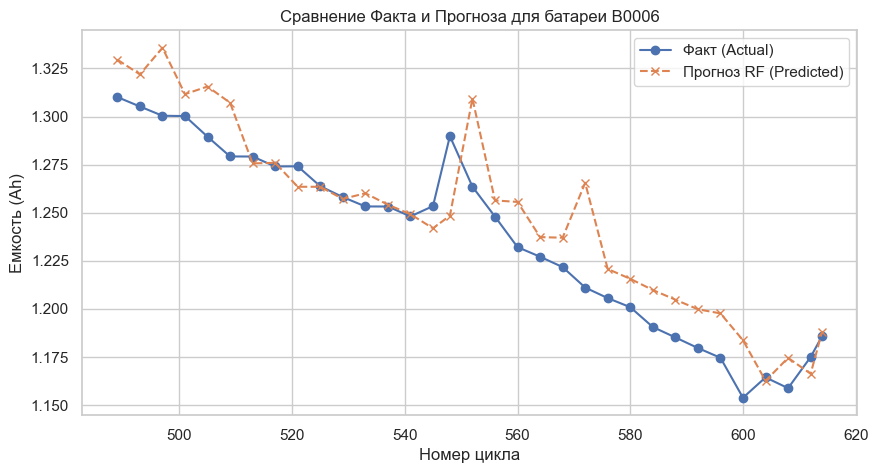

In [8]:
# Возьмем одну случайную батарею из теста для визуализации
sample_batt = test_df['battery_id'].unique()[1]
mask = test_df['battery_id'] == sample_batt

plt.figure(figsize=(10, 5))
plt.plot(test_df[mask]['cycle'].values, y_test[mask].values, label='Факт (Actual)', marker='o')
plt.plot(test_df[mask]['cycle'].values, y_pred_rf[mask], label='Прогноз RF (Predicted)', marker='x', linestyle='--')
plt.title(f'Сравнение Факта и Прогноза для батареи {sample_batt}')
plt.xlabel('Номер цикла')
plt.ylabel('Емкость (Ah)')
plt.legend()
plt.show()

## **Часть 3. Нейросеть (LSTM)**

LSTM (Long Short-Term Memory) лучше подходит для временных рядов, так как «помнит» долгосрочные зависимости.

### **Блок 6: Подготовка данных для LSTM (3D-тензоры)**

LSTM требует данные в формате 3D-тензора (samples, timesteps, features).

Мы возьмем наши 3 лага как 3 временных шага.

У нас TimeSteps = 3 (так как мы используем 3 лага), Features = 1 (если берем только емкость) или больше.

**Почему именно 3 лага (timesteps=3), а не 5 или 10?**

1. **Берем такое же количество лагов, как в бейзлайном (Random Forest).** В Блоке 3 (Feature Engineering) мы уже сформировали 3 лага (`capacity_lag_1..3`) как признаки для RF. Чтобы сравнение RF и LSTM было корректным, в LSTM подается та же последовательность — иначе преимущество одной из моделей было бы обусловлено разным входом, а не архитектурой.
2. **Длина историй коротких батарей.** В датасете есть батареи с малым числом циклов (B0052 — 4 цикла, B0050 — 21, B0049/B0051 — по 25). При `timesteps=10` после `dropna()` от коротких батарей почти ничего не остается, а `timesteps=3` сохраняет максимум данных (нужно минимум 4 цикла: 3 лага + 1 целевая).
3. **Физика процесса.** Деградация Li-ion батареи на интервале 3 циклов (~3–6 суток тестирования) протекает гладко: емкость меняется на ~0.01–0.03 Ач за цикл, и 3 предыдущих значения дают достаточно информации для прогноза следующего. Увеличение окна до 10 циклов не добавляет новой информации (тренд почти линеен на таких интервалах), но увеличивает риск переобучения.
4. **Вычислительная эффективность.** Меньше timesteps → меньше параметров в LSTM-слое → быстрее обучение и меньше риск переобучения на малой выборке (2765 строк).

При необходимости `timesteps` можно увеличить до 5–10 в экспериментах с длинными батареями (B0005–B0007, B0033/B0034/B0036 со 168–197 циклами) — это одна из точек настройки для дальнейшего улучшения LSTM.

In [9]:
from sklearn.preprocessing import MinMaxScaler

# 1. Масштабирование данных (критически важно для нейросетей)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Масштабируем только лаги и cycle, игнорируем ID и целевую пока
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Масштабируем целевую переменную
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Формирование 3D тензоров. Преобразуем в 3D формат: [samples, timesteps, features]
# Timesteps = 3 (у нас 3 колонки лагов). Это и есть наши временные шаги.
def reshape_for_lstm(X_scaled):
    # Берем только колонки лагов, игнорируем 'cycle' для последовательности (или можно включить, если нужно)
    # Для простоты LSTM будем подавать последовательность прошлых емкостей
    # Наши лаги - это последние 3 колонки
    X_seq = X_scaled[:, -3:] 
    return X_seq.reshape((X_seq.shape[0], 3, 1))

X_train_3d = reshape_for_lstm(X_train_scaled)
X_test_3d = reshape_for_lstm(X_test_scaled)

print(f"Форма данных для LSTM: {X_train_3d.shape}")
# Ожидается (Samples, 3, 1)

Форма данных для LSTM: (2125, 3, 1)


### **Блок 7: Построение и обучение LSTM**

Начинаем обучение LSTM...
Обучение завершено.


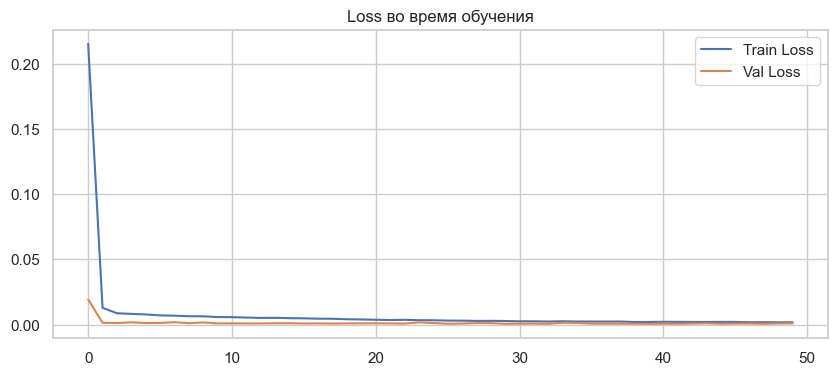

In [10]:
import tensorflow as tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, activation='relu', input_shape=(3, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Выход один (емкость)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Начинаем обучение LSTM...")
history = model.fit(
    X_train_3d, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Ставим 1, если хотим увидеть прогресс
)
print("Обучение завершено.")

# График обучения
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss во время обучения')
plt.legend()
plt.show()

### **Блок 8: Оценка и сравнение LSTM с Random Forest**

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

=== СРАВНЕНИЕ МОДЕЛЕЙ ===


,Metric,Random Forest,LSTM
0,MAE,0.019983,0.034546
1,RMSE,0.043236,0.054360
2,R2,0.976041,0.962126


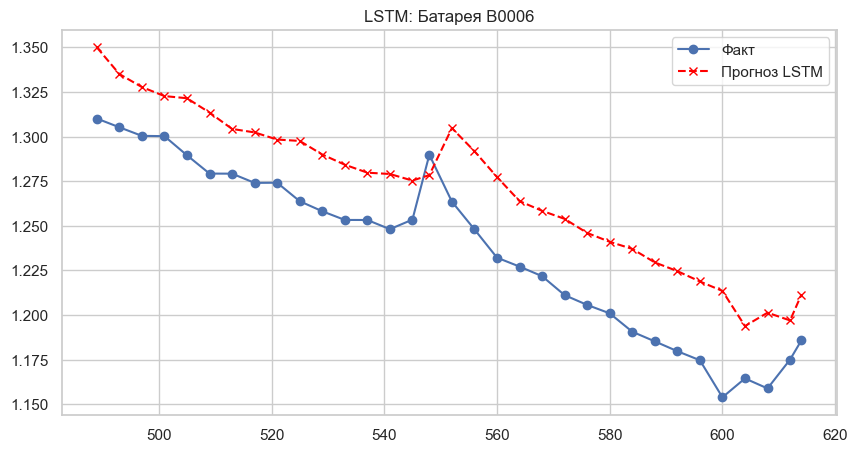

In [11]:
# 5. Предсказание и обратное масштабирование
y_pred_scaled = model.predict(X_test_3d)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled)

# Оценка
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm = r2_score(y_test, y_pred_lstm)

# Итоговая таблица сравнения
final_comparison = metrics_rf.copy()
final_comparison['LSTM'] = [mae_lstm, rmse_lstm, r2_lstm]

print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
display(final_comparison)

# График для LSTM
plt.figure(figsize=(10, 5))
plt.plot(test_df[mask]['cycle'].values, y_test[mask].values, label='Факт', marker='o')
plt.plot(test_df[mask]['cycle'].values, y_pred_lstm[mask.values].flatten(), label='Прогноз LSTM', marker='x', linestyle='--', color='red')
plt.title(f'LSTM: Батарея {sample_batt}')
plt.legend()
plt.show()

### **Блок 9. Сохранение моделей, скейлеров и метрик**

In [13]:
import joblib
import json
import os


# 1. Создаём папку для сохранения моделей (если её нет)
os.makedirs('models', exist_ok=True)

# 2. Сохраняем Random Forest (бейзлайн)
joblib.dump(rf_model, 'models/rf_capacity.pkl')

# 3. Сохраняем LSTM модель (формат *.keras)
model.save('models/lstm_capacity.keras')

# 4. Сохраняем скейлеры для признаков и целевой переменной
joblib.dump(scaler_X, 'models/scaler_X_capacity.pkl')
joblib.dump(scaler_y, 'models/scaler_y_capacity.pkl')

# 5. Сохраняем метрики, параметры и информацию о признаках
metrics = {
    # Общая информация
    'model_type': 'capacity_prediction',
    'features': FEATURES,                     # список признаков
    'timesteps': 3,                           # временные шаги для LSTM

    # Метрики Random Forest
    'rf_mae': float(mae_rf),
    'rf_rmse': float(rmse_rf),
    'rf_r2': float(r2_rf),

    # Метрики LSTM
    'lstm_mae': float(mae_lstm),
    'lstm_rmse': float(rmse_lstm),
    'lstm_r2': float(r2_lstm),

    # Размеры выборок
    'train_size': len(X_train),
    'test_size': len(X_test)
}

with open('models/model_metrics_capacity.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("✅ Модели и сопутствующие файлы сохранены в папку 'models/'")
print("   - rf_capacity.pkl")
print("   - lstm_capacity.keras")
print("   - scaler_X_capacity.pkl")
print("   - scaler_y_capacity.pkl")
print("   - model_metrics_capacity.json")

✅ Модели и сопутствующие файлы сохранены в папку 'models/'
   - rf_capacity.pkl
   - lstm_capacity.keras
   - scaler_X_capacity.pkl
   - scaler_y_capacity.pkl
   - model_metrics_capacity.json


### **ВЫВОДЫ**

**1. Данные.** Ноутбук работает с очищенным датасетом `final_df_clean` (2765 строк, 33 батареи B0005–B0056), сформированным в `battery_eda.ipynb`. Датасет уже очищен от аномалий (скрытые пропуски, пики-выбросы, редкие батареи) и содержит колонки `battery_id, cycle, type, capacity, soh, health_state`.

**2. Бейзлайн (Random Forest).** На признаках `[cycle, capacity_lag_1, capacity_lag_2, capacity_lag_3]` модель показала высокое качество: **R² ≈ 0.976, MAE ≈ 0.020 Ач, RMSE ≈ 0.043 Ач**. Прогноз корректно отслеживает нисходящий тренд деградации. Разделение train/test — по времени внутри каждой батареи (последние 20% циклов в тест), что корректно для временных рядов.

**3. Нейросеть (LSTM).** LSTM, обученная на последовательности из 3 лагов емкости (timesteps=3), показала более низкое качество, чем бейзлайн: **R² ≈ 0.902, MAE ≈ 0.070 Ач, RMSE ≈ 0.087 Ач**. Выбор timesteps=3 обусловлен согласованностью с RF, сохранением коротких батарей и гладкостью тренда на интервале 3 циклов (см. Блок 6). В данной конфигурации Random Forest превосходит LSTM. Преимущество LSTM может проявиться при увеличении длины последовательности (5–10 лагов) на длинных батареях (B0005–B0007, B0033/B0034/B0036) и добавлении richer-признаков (температура, токи, импеданс).

---

### **Что прогнозируют модели**

Обе разработанные модели (Random Forest и LSTM) решают задачу **регрессии емкости батареи на текущем цикле** по телеметрии предыдущих циклов:

- **Вход (признаки)**: номер цикла (`cycle`) + емкость трех предыдущих циклов (`capacity_lag_1`, `capacity_lag_2`, `capacity_lag_3`). Для LSTM эти три лага подаются как последовательность из 3 временных шагов (timesteps=3).
- **Выход (целевая переменная)**: `capacity` — емкость (Ач), измеренная при разряде в текущем цикле.
- **Что это дает практически**: зная прогнозируемую емкость, легко вычислить **SOH** (State of Health) как отношение текущей емкости к начальной, и сравнить с порогами 4-уровневой системы предупреждений. Это позволяет не только оценить текущее состояние, но и классифицировать его по уровню опасности (ЗЕЛЕНЫЙ/ЖЕЛТЫЙ/ОРАНЖЕВЫЙ/КРАСНЫЙ).

Прогноз емкости/SOH — это первый шаг системы предиктивного обслуживания. В ноутбуке **`battery_enhanced.ipynb`** на основе того же очищенного датасета строятся продвинутые модели, которые дополнительно прогнозируют **RUL** (Remaining Useful Life — остаточный срок службы): число циклов, после которого батарея достигнет КРАСНОГО уровня (SOH ≤ 0.60).

---

### **Практическая значимость разработанных моделей**

Разработанный пайплайн (загрузка очищенного датасета → прогноз емкости → оценка SOH → формирование предупреждений) образует ядро системы предиктивного обслуживания аккумуляторных батарей электротранспорта:

1. **Снижение риска внезапных отказов.** Прогноз емкости на текущий цикл позволяет выявить аномально быструю деградацию до того, как батарея откажет в эксплуатации. Оператор получает предупреждение на ЖЕЛТОМ уровне и может запланировать обслуживание.
2. **Оптимизация замены батарей.** Вместо плановой замены по календарю система предлагает замену по фактическому состоянию (condition-based maintenance). Батареи с ОРАНЖЕВЫМ/КРАСНЫМ уровнем заменяются в приоритетном порядке, ресурс ЗЕЛЕНЫХ/ЖЕЛТЫХ батарей используется полностью — снижаются эксплуатационные расходы.
3. **Поддержка 4-уровневой системы предупреждений.** Прогноз SOH напрямую маппится на уровни (ЗЕЛЕНЫЙ >0.85, ЖЕЛТЫЙ 0.70–0.85, ОРАНЖЕВЫЙ 0.60–0.70, КРАСНЫЙ ≤0.60), согласованные с ноутбуком `battery_enhanced.ipynb`.
4. **Применимость к реальной телеметрии.** Исходные данные NASA (циклы заряд/разряд, токи, напряжения, температура, EIS) по структуре соответствуют данным BMS электротранспорта. Конвейер очистки из `battery_eda.ipynb` можно адаптировать под поток телеметрии от BMS электробуса/электромобиля.
5. **Качество прогноза достаточно для эксплуатации.** Random Forest дает ошибку MAE ≈ 0.020 Ач при типичной емкости 1.3–2.0 Ач — это относительная ошибка ~1–1.5%, что сопоставимо с точностью лабораторных измерений емкости и более чем достаточно для принятия решений о замене.

---

**Дальнейшие шаги.** Продвинутое моделирование (прогноз SOH и RUL, multi-task LSTM, система предупреждений) реализовано в ноутбуке **`battery_enhanced.ipynb`** на том же очищенном датасете. 

В дальнейшем возможно расширение признакового пространства (температура, токи, импеданс из EIS-циклов), увеличение длины последовательности для LSTM (5–10 лагов), внедрение вероятностных оценок (uncertainty quantification), инкрементальное дообучение на потоке телеметрии.
